In [1]:
import pickle

# Load the pickle file
with open('../network_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [2]:
print(data)

{'nodes': [{'id': '134', 'group': 'Consensus (hard fork)', 'compliance_score': 82.35, 'created': '2016-07-27', 'author': ['Tom Zander <tomz@freedommail.ch>'], 'word_list': {'transaction': 32, 'we': 24, 'transactions': 16, 'format': 15, 'can': 15, 'input': 15, 'not': 14, 'tokens': 12, 'signatures': 12, 'future': 10, 'all': 9, 'new': 9, 'data': 9, 'have': 9, 'amount': 9, 'any': 9, 'version': 8, 'like': 8, 'fields': 8, 'they': 8, 'optional': 8, 'hash': 8, 'bitcoin': 7, 'use': 7, 'name': 7, 'spec': 7, 'without': 7, 'if': 7, 'bip': 6, 'flexible': 6, '4': 6, '0': 6, 'token': 6, 'which': 6, 'means': 6, 'integer': 6, 'order': 6, 'id': 6, 'spending': 6, 'bytearray': 6, 'used': 6, 'https': 5, 'github': 5, 'com': 5, 'following': 5, 'cmf': 5, 'based': 5, 'value': 5, 'after': 5, 'blob': 5, 'part': 5, 'tx': 5, 'signature': 5, 'v4': 5, 'txend': 5, 'implementation': 5, 'comments': 4, 'type': 4, 'next': 4, 'same': 4, 'time': 4, 'malleability': 4, 'message': 4, 'where': 4, 'because': 4, 'added': 4, 'upg

In [3]:
import matplotlib.pyplot as plt
from collections import Counter
import re

In [4]:
# Assuming `data` is the final network data from earlier
nodes = data['nodes']

In [5]:
# Count BIPs per author
author_counts = Counter()

for bip in nodes:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = re.split(r'<', author)[0].strip()  # Remove emails like "Name <email>"
            author_counts[name] += 1


In [6]:
# Get top 10 authors
top_authors = author_counts.most_common(10)
authors, counts = zip(*top_authors)

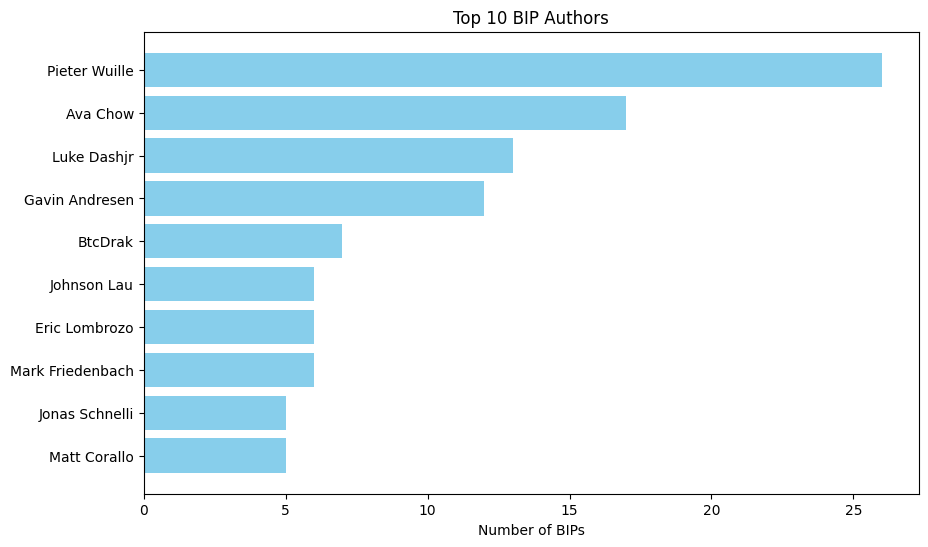

In [7]:
# Plotting
plt.figure(figsize=(10, 6))
bars = plt.barh(authors, counts, color='skyblue')
plt.xlabel('Number of BIPs')
plt.title('Top 10 BIP Authors')
plt.gca().invert_yaxis()  # Highest at top

In [8]:
from collections import Counter
from datetime import datetime

In [9]:
# Extract and count BIPs per year from the nodes
years = []

for node in data['nodes']:
    created = node.get('created')
    if created:
        try:
            # Normalize date format to extract year
            year = datetime.strptime(created, "%Y-%m-%d").year
            years.append(year)
        except ValueError:
            continue  # skip malformed dates

In [10]:
year_counts = Counter(years)
sorted_years = sorted(year_counts.items())  # (year, count)

In [11]:
# Prepare data for plotting
x_years, y_counts = zip(*sorted_years)

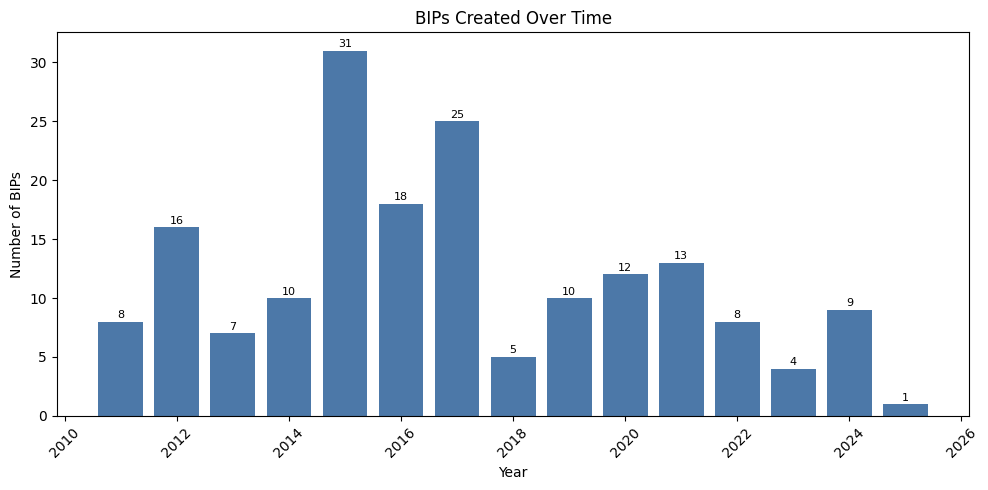

In [12]:
# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(x_years, y_counts, color="#4c78a8")

plt.xlabel("Year")
plt.ylabel("Number of BIPs")
plt.title("BIPs Created Over Time")
plt.xticks(rotation=45)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, str(height), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
from collections import Counter
import matplotlib.pyplot as plt
# Step 1: Count BIPs per author
author_bip_counts = Counter()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            author_bip_counts[name] += 1


In [14]:
# Step 2: Count how many authors have written N BIPs
contribution_distribution = Counter(author_bip_counts.values())

In [15]:
# Sort by number of BIPs
sorted_counts = sorted(contribution_distribution.items())
x_vals, y_vals = zip(*sorted_counts)

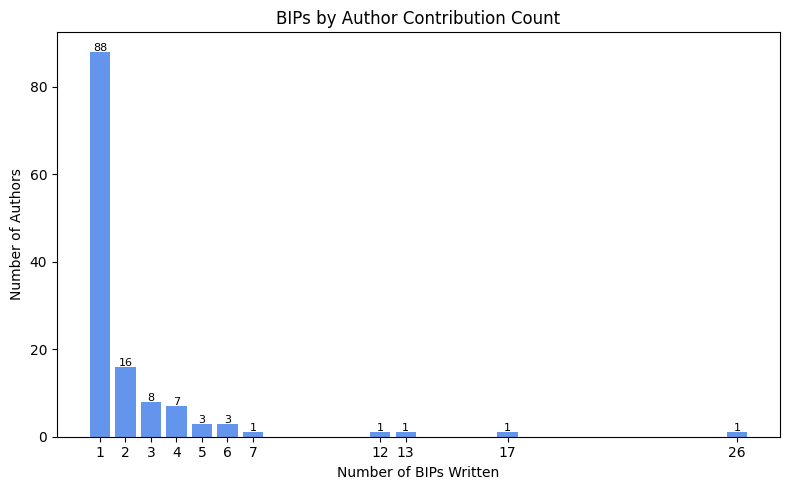

In [16]:
# Step 3: Plot histogram
plt.figure(figsize=(8, 5))
bars = plt.bar(x_vals, y_vals, color='cornflowerblue')

plt.xlabel("Number of BIPs Written")
plt.ylabel("Number of Authors")
plt.title("BIPs by Author Contribution Count")
plt.xticks(x_vals)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.2, str(height), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
from collections import Counter

# Step 1: Count BIPs per author
author_bip_counts = Counter()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            author_bip_counts[name] += 1

# Step 2: Get total number of BIPs (based on distinct BIP IDs)
total_bips = len({bip['id'] for bip in data['nodes'] if 'id' in bip})

# Step 3: Get top 10 authors
top_10 = author_bip_counts.most_common(10)

# Step 4: Compute total BIPs by top 10 authors
bips_by_top_10 = sum(count for _, count in top_10)

# Step 5: Compute percentage
percentage = (bips_by_top_10 / total_bips) * 100

# Step 6: Print results
print("Top 10 BIP Authors (by number of BIPs):")
for author, count in top_10:
    print(f" - {author}: {count} BIPs")

print(f"\nTotal BIPs: {total_bips}")
print(f"BIPs by Top 10 Authors: {bips_by_top_10}")
print(f"Percentage of all BIPs: {percentage:.2f}%")


Top 10 BIP Authors (by number of BIPs):
 - Pieter Wuille: 26 BIPs
 - Ava Chow: 17 BIPs
 - Luke Dashjr: 13 BIPs
 - Gavin Andresen: 12 BIPs
 - BtcDrak: 7 BIPs
 - Johnson Lau: 6 BIPs
 - Eric Lombrozo: 6 BIPs
 - Mark Friedenbach: 6 BIPs
 - Jonas Schnelli: 5 BIPs
 - Matt Corallo: 5 BIPs

Total BIPs: 177
BIPs by Top 10 Authors: 103
Percentage of all BIPs: 58.19%


In [18]:
# Step 7: Count unique authors
unique_authors = set()

for bip in data['nodes']:
    authors = bip.get('author')
    if isinstance(authors, list):
        for author in authors:
            name = author.split('<')[0].strip()
            unique_authors.add(name)

num_unique_authors = len(unique_authors)

# Display
print(f"\nTotal Unique Authors: {num_unique_authors}")



Total Unique Authors: 130


In [19]:
import networkx as nx
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt

def build_collaboration_network(data):
    G = nx.Graph()  # Undirected graph

    coauthor_counts = defaultdict(int)

    for bip in data['nodes']:
        authors = bip.get('author', [])
        if isinstance(authors, list) and len(authors) > 1:
            # Clean author names (strip email)
            clean_authors = [a.split('<')[0].strip() for a in authors]
            for a1, a2 in combinations(clean_authors, 2):
                # Sort to avoid (a,b) and (b,a) as separate pairs
                key = tuple(sorted([a1, a2]))
                coauthor_counts[key] += 1

    # Add nodes and edges
    for (a1, a2), weight in coauthor_counts.items():
        G.add_edge(a1, a2, weight=weight)

    return G


In [20]:
def draw_collaboration_network(G):
    plt.figure(figsize=(12, 8))

    pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges]

    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=800, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title("BIP Author Collaboration Network")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


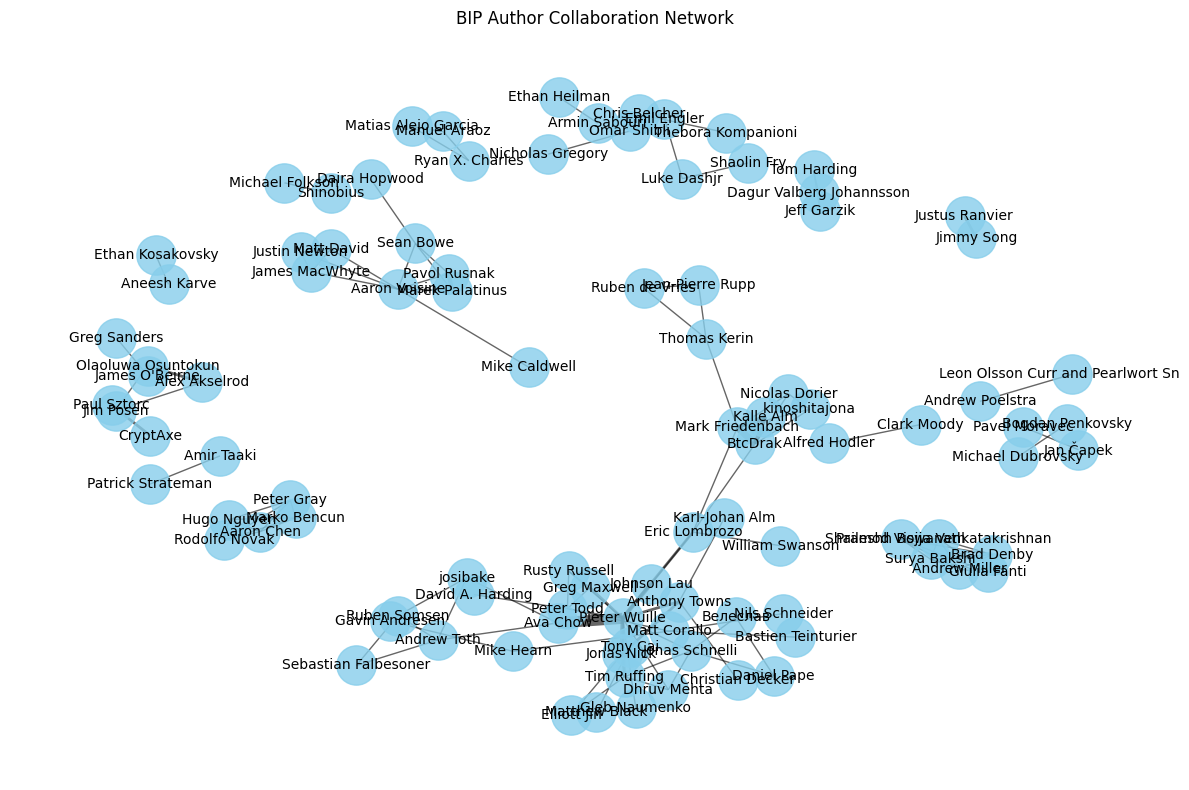

In [21]:
G_collab = build_collaboration_network(data)
draw_collaboration_network(G_collab)

In [22]:
def compute_centrality_scores(G):
    degree = nx.degree_centrality(G)
    betweenness = nx.betweenness_centrality(G)
    closeness = nx.closeness_centrality(G)
    eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

    centrality_data = []
    for node in G.nodes():
        centrality_data.append({
            'Author': node,
            'Degree': degree[node],
            'Betweenness': betweenness[node],
            'Closeness': closeness[node],
            'Eigenvector': eigenvector[node]
        })
    
    return sorted(centrality_data, key=lambda x: x['Eigenvector'], reverse=True)


In [27]:
centrality_results = compute_centrality_scores(G_collab)

# Print top 5 most critical authors by eigenvector centrality
for entry in centrality_results[:10]:
    print(f"{entry['Author']} - Eigenvector: {entry['Eigenvector']:.3f}, Degree: {entry['Degree']:.2f}")


Andrew Miller - Eigenvector: 0.408, Degree: 0.05
Brad Denby - Eigenvector: 0.408, Degree: 0.05
Giulia Fanti - Eigenvector: 0.408, Degree: 0.05
Surya Bakshi - Eigenvector: 0.408, Degree: 0.05
Shaileshh Bojja Venkatakrishnan - Eigenvector: 0.408, Degree: 0.05
Pramod Viswanath - Eigenvector: 0.408, Degree: 0.05
Pieter Wuille - Eigenvector: 0.000, Degree: 0.12
Tim Ruffing - Eigenvector: 0.000, Degree: 0.05
Jonas Schnelli - Eigenvector: 0.000, Degree: 0.05
Jonas Nick - Eigenvector: 0.000, Degree: 0.04


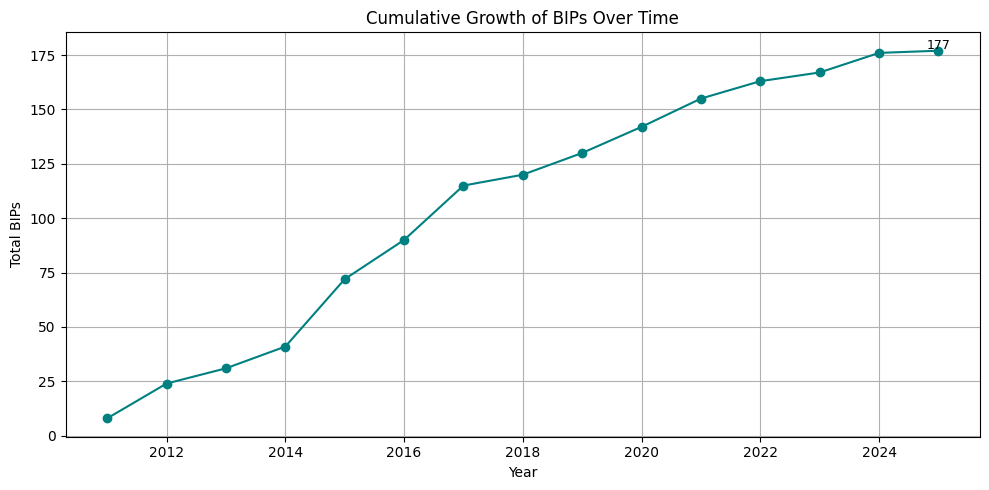

In [28]:
from datetime import datetime
from collections import Counter
import matplotlib.pyplot as plt

# Step 1: Count BIPs per year
years = []

for node in data['nodes']:
    created = node.get('created')
    if created:
        try:
            year = datetime.strptime(created, "%Y-%m-%d").year
            years.append(year)
        except ValueError:
            continue

# Step 2: Sort years and compute cumulative total
year_counts = Counter(years)
all_years = sorted(year_counts.keys())

cumulative_counts = []
running_total = 0
for year in all_years:
    running_total += year_counts[year]
    cumulative_counts.append(running_total)

# Step 3: Plot cumulative line chart
plt.figure(figsize=(10, 5))
plt.plot(all_years, cumulative_counts, marker='o', linestyle='-', color='teal')

plt.title("Cumulative Growth of BIPs Over Time")
plt.xlabel("Year")
plt.ylabel("Total BIPs")
plt.grid(True)

# Annotate final value
plt.text(all_years[-1], cumulative_counts[-1] + 1, str(cumulative_counts[-1]), ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [32]:
from collections import defaultdict, Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Count BIPs by status per year
status_by_year = defaultdict(Counter)

for node in data['nodes']:
    created = node.get('created')
    status = node.get('status', 'Unknown').capitalize()

    if created:
        try:
            year = datetime.strptime(created, "%Y-%m-%d").year
            status_by_year[year][status] += 1
        except ValueError:
            continue


In [33]:
# Define the statuses you're interested in
statuses = ['Draft', 'Final', 'Rejected']
years = sorted(status_by_year.keys())

# Create a list of values for each status across years
status_counts = {status: [] for status in statuses}
for year in years:
    for status in statuses:
        status_counts[status].append(status_by_year[year].get(status, 0))


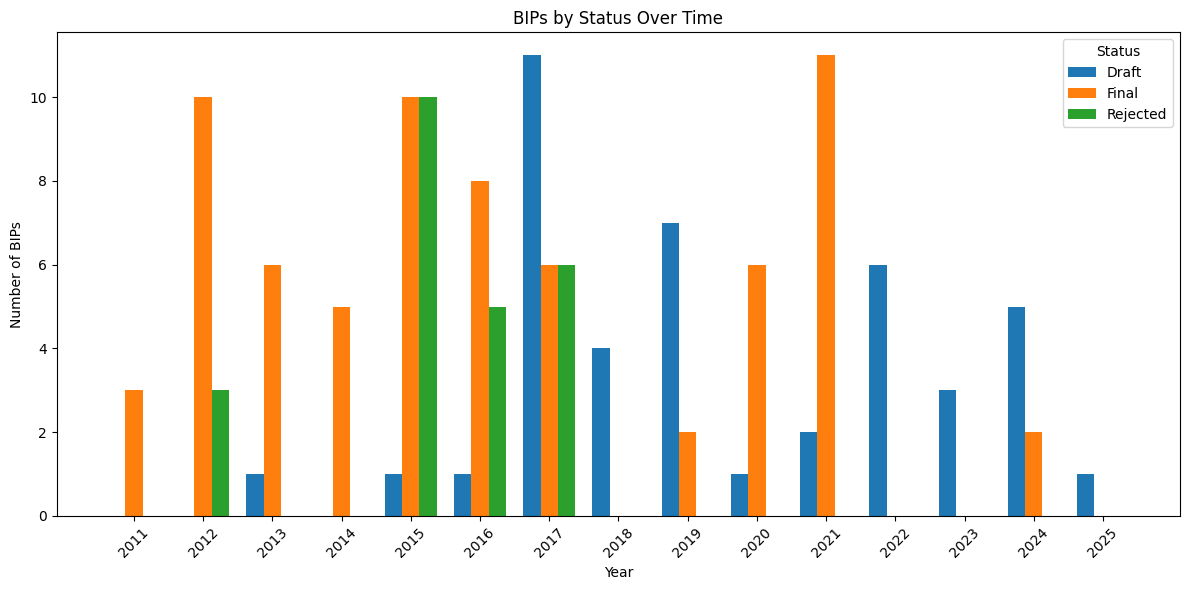

In [34]:
bar_width = 0.25
x = np.arange(len(years))  # positions for bars

plt.figure(figsize=(12, 6))

for i, status in enumerate(statuses):
    offset = (i - 1) * bar_width  # centers the groups
    plt.bar(x + offset, status_counts[status], width=bar_width, label=status)

plt.xticks(x, years, rotation=45)
plt.xlabel("Year")
plt.ylabel("Number of BIPs")
plt.title("BIPs by Status Over Time")
plt.legend(title="Status")
plt.tight_layout()
plt.show()


In [ ]:
# move chart to RQ2